In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

In [ ]:
# Generate customer names
customers = [
    "Amit", "Neha", "Rahul", "Priya", "Vikram", "Sonia", "Manish", "Kavita", "Rajesh", "Deepika",
    "Arjun", "Pooja", "Ravi", "Simran", "Anil", "Megha", "Suresh", "Divya", "Tarun", "Shweta" ]

In [ ]:
# Generate synthetic data
np.random.seed(42)
data = {
    "Customer Name": customers,
    "Age": np.random.randint(18, 65, 20),
    "Annual Income (₹ Lakhs)": np.random.uniform(2, 50, 20).round(2),  # ₹2L to ₹50L
    "Spending Score (1-100)": np.random.randint(1, 101, 20),
    "Avg Transaction Value (₹ Thousands)": np.random.uniform(1, 100, 20).round(2),  # ₹1K to ₹100K
    "Customer Type": np.random.choice(["Regular", "Premium", "Occasional"], 20)
}
df = pd.DataFrame(data)
df.head()

,Customer Name,Age,Annual Income (₹ Lakhs),Spending Score (1-100),Avg Transaction Value (₹ Thousands),Customer Type
0,Amit,56,47.05,18,19.04,Regular
1,Neha,46,2.04,4,75.78,Regular
2,Rahul,32,49.63,89,43.09,Regular
3,Priya,60,31.64,60,21.59,Occasional
4,Vikram,25,31.36,14,57.20,Regular


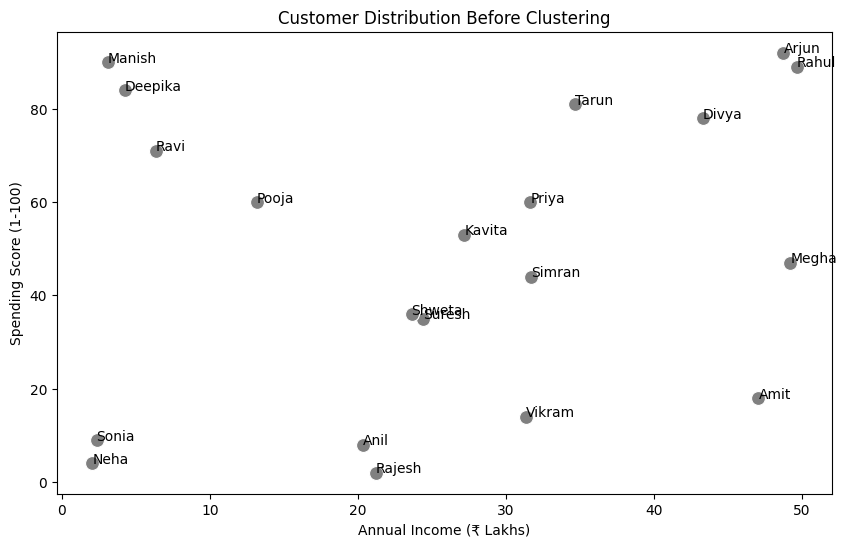

In [ ]:
plt.figure(figsize=(10, 6))

# Scatter plot before clustering
sns.scatterplot(x=df["Annual Income (₹ Lakhs)"], y=df["Spending Score (1-100)"], s=100, color="gray")

# Annotate customer names
for i, txt in enumerate(df["Customer Name"]):
    plt.annotate(txt, (df["Annual Income (₹ Lakhs)"][i], df["Spending Score (1-100)"][i]), fontsize=10)

plt.xlabel("Annual Income (₹ Lakhs)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customer Distribution Before Clustering")
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler

# Select relevant columns
X = df[["Annual Income (₹ Lakhs)", "Spending Score (1-100)"]]

In [ ]:
# Apply K-Means
optimal_k = 3  # Assume 3 clusters
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(X)

In [ ]:
# Define Cluster Labels
cluster_labels = {
    0: "Low Spenders",
    1: "Moderate Spenders",
    2: "High Spenders"
}

In [ ]:
df["Segment"] = df["Cluster"].map(cluster_labels)

In [ ]:
print(df[["Customer Name", "Age", "Annual Income (₹ Lakhs)", "Spending Score (1-100)", "Segment"]])

   Customer Name  Age  Annual Income (₹ Lakhs)  Spending Score (1-100)  \
0           Amit   56                    47.05                      18   
1           Neha   46                     2.04                       4   
2          Rahul   32                    49.63                      89   
3          Priya   60                    31.64                      60   
4         Vikram   25                    31.36                      14   
5          Sonia   38                     2.34                       9   
6         Manish   56                     3.11                      90   
7         Kavita   36                    27.19                      53   
8         Rajesh   40                    21.19                       2   
9        Deepika   28                     4.24                      84   
10         Arjun   28                    48.74                      92   
11         Pooja   41                    13.17                      60   
12          Ravi   53                 

<Axes: xlabel='Annual Income (₹ Lakhs)', ylabel='Spending Score (1-100)'>

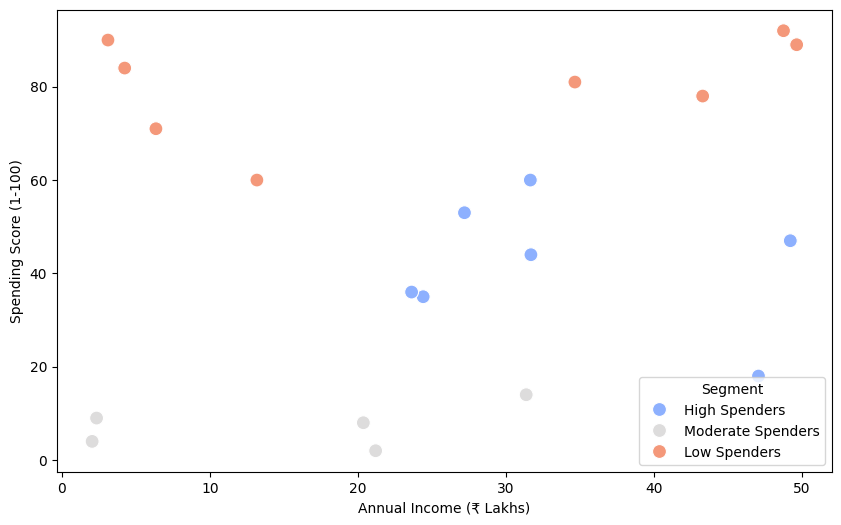

In [ ]:
plt.figure(figsize=(10, 6))
# Scatter plot after clustering
sns.scatterplot(
    x=df["Annual Income (₹ Lakhs)"], y=df["Spending Score (1-100)"],
    hue=df["Segment"], palette="coolwarm", s=100 )

/tmp/ipython-input-2521832716.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Customer Segment")


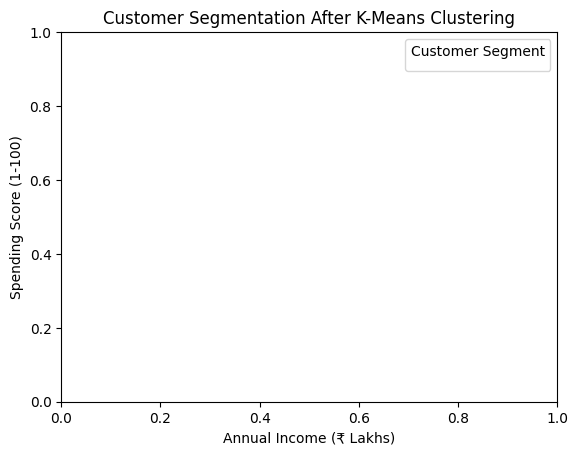

In [ ]:
# Annotate customer names
for i, txt in enumerate(df["Customer Name"]):
    plt.annotate(txt, (df["Annual Income (₹ Lakhs)"][i], df["Spending Score (1-100)"][i]), fontsize=10)

plt.xlabel("Annual Income (₹ Lakhs)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customer Segmentation After K-Means Clustering")
plt.legend(title="Customer Segment")
plt.show()

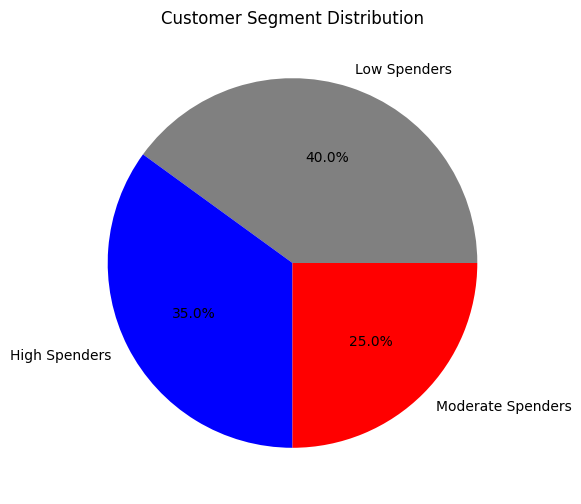

In [ ]:
plt.figure(figsize=(6, 6))
df["Segment"].value_counts().plot.pie(autopct="%1.1f%%", colors=["gray", "blue", "red"])
plt.title("Customer Segment Distribution")
plt.ylabel("")
plt.show()

/tmp/ipython-input-1052021898.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df["Segment"], y=df["Spending Score (1-100)"], palette="coolwarm")


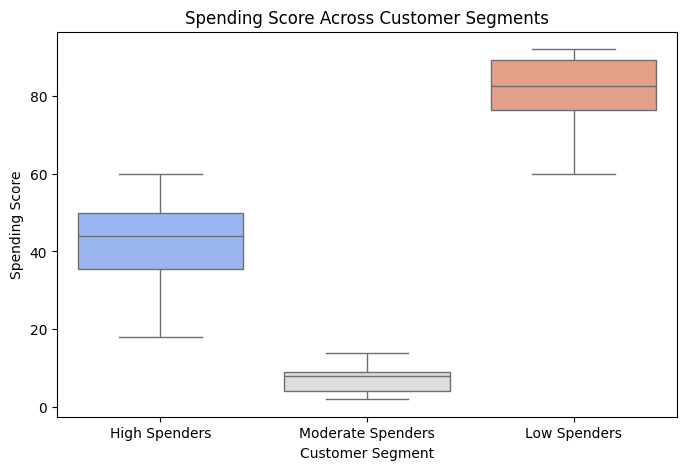

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df["Segment"], y=df["Spending Score (1-100)"], palette="coolwarm")
plt.title("Spending Score Across Customer Segments")
plt.xlabel("Customer Segment")
plt.ylabel("Spending Score")
plt.show()

In [ ]:
<ipython-input-10-739602d12d12>:2: FutureWarning:
Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0.
Assign the `x` variable to `hue` and set `legend=False` for the same effect.
sns.boxplot(x=df["Segment"], y=df["Spending Score (1-100)"], palette="coolwarm")

In [25]:
def categorize_spender(score):
    if score <= 40:
        return "Low Spender"
    elif 41 <= score <= 70:
        return "Moderate Spender"
    else:
        return "High Spender"

In [26]:
df["Purchasing Level"] = df["Spending Score (1-100)"].apply(categorize_spender)
df["Purchasing Level"]

,Purchasing Level
0,Low Spender
1,Low Spender
2,High Spender
3,Moderate Spender
4,Low Spender
5,Low Spender
6,High Spender
7,Moderate Spender
8,Low Spender
9,High Spender


In [ ]:
df.columns

Index(['Customer Name', 'Age', 'Annual Income (₹ Lakhs)',
       'Spending Score (1-100)', 'Avg Transaction Value (₹ Thousands)',
       'Customer Type', 'Cluster', 'Segment'],
      dtype='object')

In [ ]:
df['Customer Name']

,Customer Name
0,Amit
1,Neha
2,Rahul
3,Priya
4,Vikram
5,Sonia
6,Manish
7,Kavita
8,Rajesh
9,Deepika


In [ ]:
df['Spending Score (1-100)']

,Spending Score (1-100)
0,18
1,4
2,89
3,60
4,14
5,9
6,90
7,53
8,2
9,84


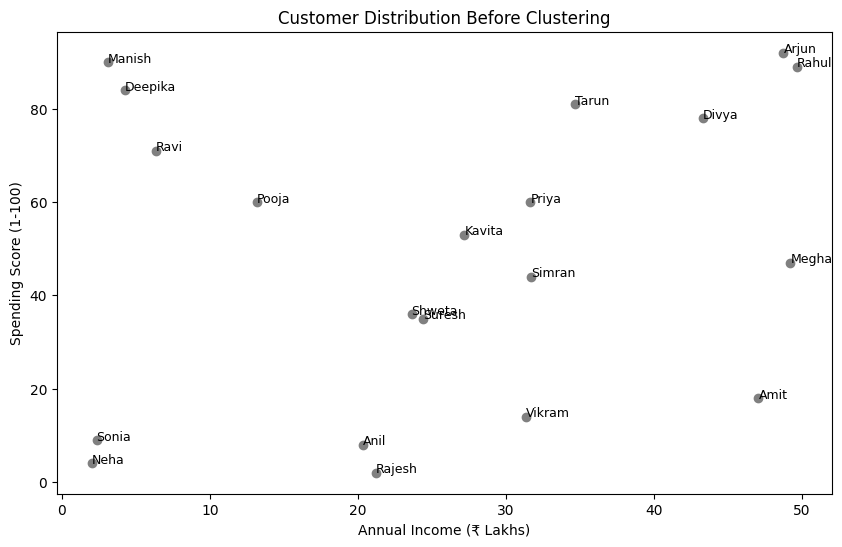

In [27]:
plt.figure(figsize=(10, 6))
for i in range(len(df)):
    plt.scatter(df["Annual Income (₹ Lakhs)"][i], df["Spending Score (1-100)"][i], color="gray")
    plt.text(df["Annual Income (₹ Lakhs)"][i], df["Spending Score (1-100)"][i], df["Customer Name"][i], fontsize=9)
plt.xlabel("Annual Income (₹ Lakhs)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customer Distribution Before Clustering")
plt.show()

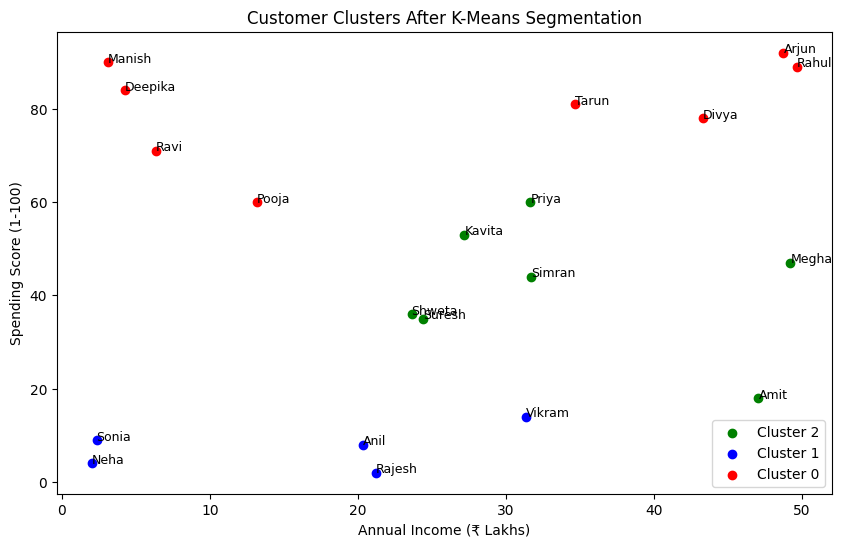

In [28]:
plt.figure(figsize=(10, 6))
colors = {0: "red", 1: "blue", 2: "green"}
for i in range(len(df)):
    plt.scatter(df["Annual Income (₹ Lakhs)"][i], df["Spending Score (1-100)"][i],
                color=colors[df["Cluster"][i]], label=f"Cluster {df['Cluster'][i]}" if i < 3 else "")
    plt.text(df["Annual Income (₹ Lakhs)"][i], df["Spending Score (1-100)"][i], df["Customer Name"][i], fontsize=9)

plt.xlabel("Annual Income (₹ Lakhs)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customer Clusters After K-Means Segmentation")
plt.legend()
plt.show()

In [29]:
summary = df.groupby("Cluster").agg({
    "Age": "mean",
    "Annual Income (₹ Lakhs)": "mean",
    "Spending Score (1-100)": "mean",
    "Purchasing Level": lambda x: x.mode()[0]  # Most common category in each cluster
}).rename(columns={"Age": "Avg Age", "Annual Income (₹ Lakhs)": "Avg Income (₹ L)", "Spending Score (1-100)": "Avg Score"})

print(summary)

         Avg Age  Avg Income (₹ L)  Avg Score  Purchasing Level
Cluster                                                        
0          37.25          25.39625  80.625000      High Spender
1          38.00          15.45800   7.400000       Low Spender
2          47.00          33.54000  41.857143  Moderate Spender


# THE END